Principal Components:
[[ 0.91290939 -0.00586388  0.40806573  0.00666444]
 [-0.00512641 -0.22972907 -0.00772683  0.97321045]]
Explained Variance Ratio:
[0.81899053 0.14169335]
Number of Components:
2
Explained Variance:
[4014.54665281  694.55574301]


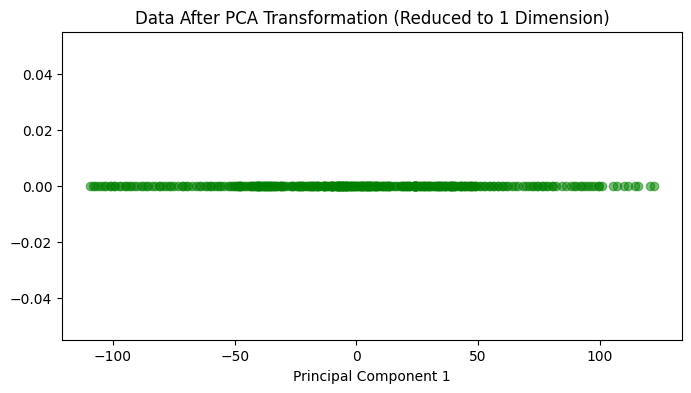

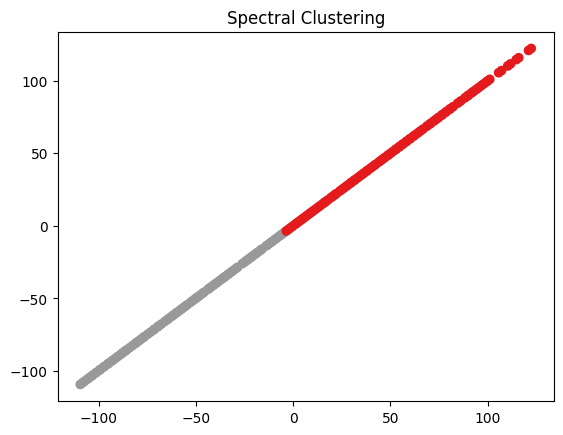

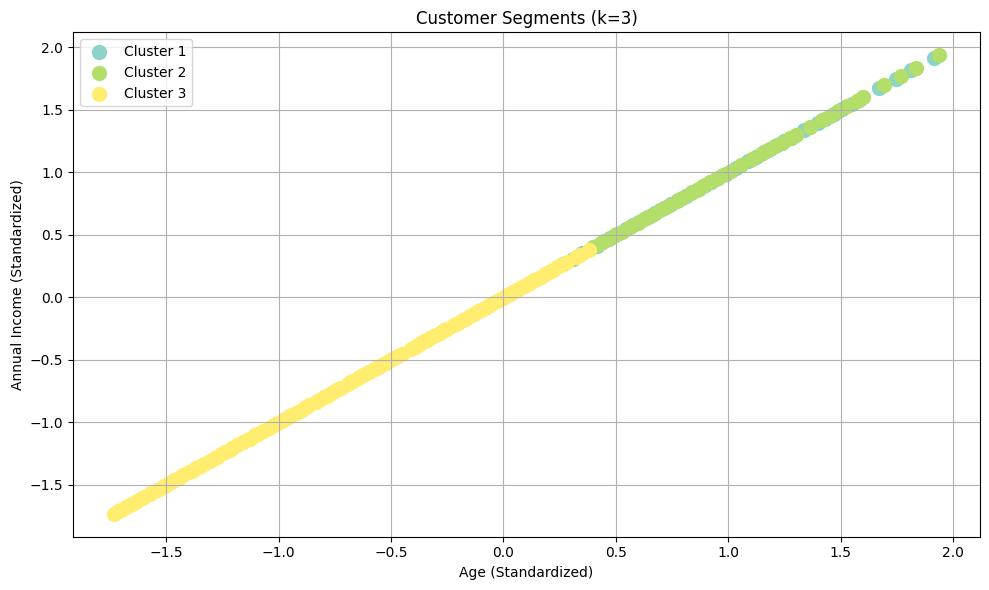

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        41.146341           85.487805               20.341463
1        32.692308           86.538462               82.128205
2        40.066667           43.600000               50.025000


In [13]:
# Step 0: Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.decomposition import PCA
import pandas as pd

# Step 1: Generate random 2D data points that are linearly correlated
np.random.seed(42)
x = np.random.normal(0, 1, 100)
y = 2.5 * x + np.random.normal(0, 1, 100)
data = np.column_stack((x, y))

data = pd.read_csv('Mall_Customers.csv')
data.drop("Genre", axis=1, inplace=True)
X = data[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

# Step 2: Standardize the data
data_centered = data - np.mean(data, axis=0)

# Step 3: Compute the Covariance Matrix
cov_matrix = np.cov(data_centered, rowvar=False)

# Step 4: Calculate Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 5: Plot original data and principal components
# plt.figure(figsize=(8, 6))
# plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.5)
# for i in range(len(eigenvalues)):
#     plt.arrow(0, 0, eigenvectors[i, 0] * eigenvalues[i], eigenvectors[i, 1] * eigenvalues[i],
#               color='r', width=0.02, label=f'Principal Component {i+1}')
# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')
# plt.title('Data with Principal Components')
# plt.legend()
# plt.show()

# Step 6: Transform the data to the new coordinate system (2D to 1D reduction)
pca = PCA(n_components=2)
data_reduced = pca.fit_transform(data_centered)
print("Principal Components:")
print(pca.components_)
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Number of Components:")
print(pca.n_components_)
print("Explained Variance:")
print(pca.explained_variance_)

# Step 7: Visualize the Reduced Data
plt.figure(figsize=(8, 4))
plt.scatter(data_reduced, np.zeros_like(data_reduced), alpha=0.5, color='g')
plt.title('Data After PCA Transformation (Reduced to 1 Dimension)')
plt.xlabel('Principal Component 1')
plt.show()

X=data_reduced
# Initialize Spectral Clustering model
model = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    n_neighbors=15
)

# Fit model and assign cluster labels
labels = model.fit_predict(X)

plt.scatter(X[:, 0], X[:, 0], c=labels, cmap='Set1')
plt.title("Spectral Clustering")
plt.show()


# Use 3 clusters
X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Cluster visualization
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    ax.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 0], 
                s=100, c=[colors[i]], label=f'Cluster {i+1}')
# ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            # s=300, c='red', marker='X', label='Centroids')
ax.set_title(f'Customer Segments (k={optimal_k})')
ax.set_xlabel('Age (Standardized)')
ax.set_ylabel('Annual Income (Standardized)')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

data['Cluster'] = y_kmeans
print(data.groupby('Cluster').agg({'Age': 'mean', 'Annual Income (k$)': 'mean', 'Spending Score (1-100)': 'mean'}))